In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_co60_spectrum(num_events=100000, resolution_at_662=0.07):
    # Co-60 gamma energies in MeV
    energies = [1.1732, 1.3325]
    
    # Electron rest mass in MeV
    m_e = 0.511 
    
    deposited_energies = []
    
    # Photofraction (probability of full energy deposition)
    # Roughly 20% for a standard 3x3 inch NaI(Tl) crystal at these energies
    photofraction = 0.20 
    
    for _ in range(num_events):
        # Co-60 emits these in a cascade, so they have equal probability
        E_inc = np.random.choice(energies)
        
        # Determine interaction type
        if np.random.random() < photofraction:
            # Full energy deposition (Photoelectric effect or multiple scatters)
            E_dep = E_inc
        else:
            # Compton scattering (single scatter, photon escapes)
            # Max energy transferred to electron (Compton edge)
            E_edge = E_inc * (2 * E_inc / m_e) / (1 + 2 * E_inc / m_e)
            
            # Simplified Klein-Nishina: uniform distribution up to Compton edge 
            E_dep = np.random.uniform(0, E_edge)
            
        deposited_energies.append(E_dep)
        
    deposited_energies = np.array(deposited_energies)
    
    # --- PMT / Scintillation Statistics Simulation ---
    # Apply detector resolution (Gaussian broadening)
    # PMT resolution scales as 1/sqrt(E) due to Poisson statistics of photoelectrons
    # FWHM = resolution * E. Standard deviation (sigma) = FWHM / 2.355
    
    sigma_662 = (resolution_at_662 * 0.662) / 2.355
    
    # Calculate sigma for each specific deposited energy
    sigmas = sigma_662 * np.sqrt(deposited_energies / 0.662 + 1e-6)
    
    # Smear the deposited energies to get the "measured" MCA channels
    measured_energies = np.random.normal(deposited_energies, sigmas)
    
    # Filter out impossible negative energies from smearing near 0
    measured_energies = measured_energies[measured_energies > 0]
    
    return measured_energies

# Run simulation
print("Simulating 200,000 particle interactions...")
energies = simulate_co60_spectrum(num_events=200000, resolution_at_662=0.07)

# Plotting the spectrum
plt.figure(figsize=(12, 6))
plt.hist(energies, bins=500, range=(0, 1.6), color='#2ca02c', alpha=0.8, edgecolor='none')
plt.title('Monte Carlo Simulated NaI(Tl) Spectrum for Co-60', fontsize=14)
plt.xlabel('Energy (MeV)', fontsize=12)
plt.ylabel('Counts per Bin', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Annotate the true physical photopeaks
plt.axvline(1.173, color='black', linestyle='dashed', alpha=0.5)
plt.axvline(1.332, color='black', linestyle='dashed', alpha=0.5)
plt.text(1.18, plt.ylim()[1]*0.9, '1.17 MeV Peak', color='black')
plt.text(1.34, plt.ylim()[1]*0.8, '1.33 MeV Peak', color='black')

plt.tight_layout()
plt.show()

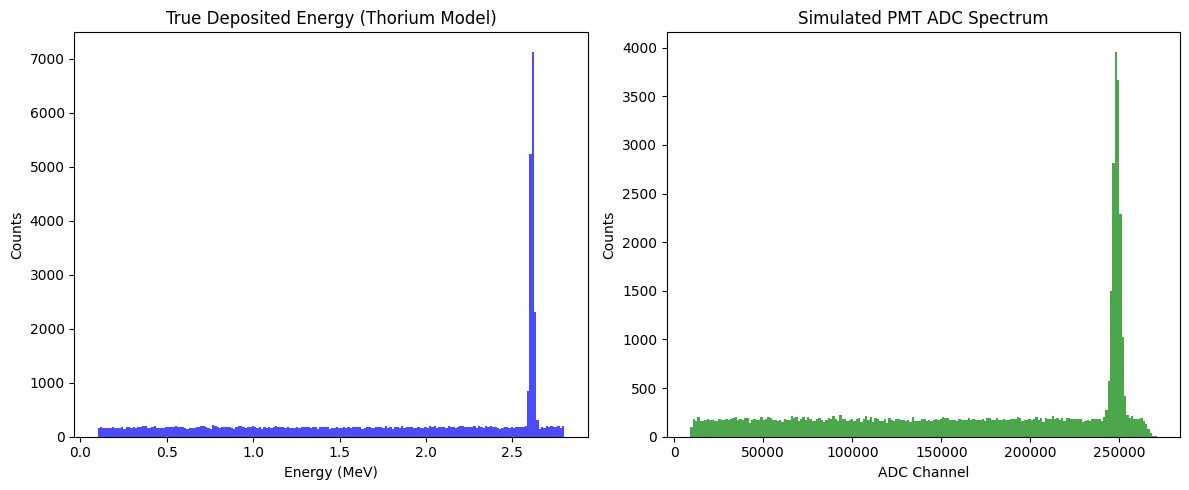

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_pmt_data(num_events=50000):
    """
    Simulates the response of a Scintillator + PMT setup to a Thorium source.
    """
    # --- 1. Define Physics & Hardware Parameters ---
    
    # Scintillator parameters (e.g., NaI(Tl))
    light_yield = 38000  # Photons per MeV of deposited energy
    
    # PMT parameters
    qe = 0.25            # Quantum Efficiency (25% of photons create a photoelectron)
    mean_gain = 1e6      # Average amplification factor of the dynode chain
    gain_sigma = 0.5e6   # Spread in the gain (simulates resolution/fluctuations)
    
    # Electronics/DAQ parameters
    pedestal_mean = 50   # Baseline ADC value with no signal
    pedestal_sigma = 5   # Electronic noise width
    adc_conversion = 1e-5 # Factor to convert raw charge to an ADC bin
    
    # --- 2. Generate Incident "Thorium" Energy Spectrum ---
    # We will simulate two types of events: Compton continuum (background) and a Photopeak
    
    # Simulate a flat-ish Compton background
    bg_energies = np.random.uniform(low=0.1, high=2.8, size=int(num_events * 0.7))
    
    # Simulate the prominent 2.614 MeV Tl-208 peak from the Thorium decay chain
    peak_energies = np.random.normal(loc=2.614, scale=0.01, size=int(num_events * 0.3))
    
    # Combine into one array of true deposited energies (in MeV)
    true_energies = np.concatenate([bg_energies, peak_energies])
    
    # --- 3. Monte Carlo Simulation Loop (Vectorized for speed) ---
    
    # Step A: Energy to Photons (Poisson statistics)
    # Expected photons = Energy * Light Yield
    expected_photons = true_energies * light_yield
    actual_photons = np.random.poisson(expected_photons)
    
    # Step B: Photons to Photoelectrons (PE) at the photocathode (Binomial statistics)
    # Each photon has a 'qe' chance of creating an electron
    photoelectrons = np.random.binomial(n=actual_photons, p=qe)
    
    # Step C: Dynode Gain Multiplication (Gaussian approximation of the cascade)
    # Only calculate gain for events that produced at least 1 PE
    valid_events = photoelectrons > 0
    
    # The total gain variance scales with the square root of the number of PEs
    event_gain_sigma = np.sqrt(photoelectrons[valid_events]) * gain_sigma
    total_charge = np.zeros_like(photoelectrons, dtype=float)
    
    # Draw the amplified charge for valid events
    total_charge[valid_events] = np.random.normal(
        loc=photoelectrons[valid_events] * mean_gain, 
        scale=event_gain_sigma
    )
    
    # Step D: Electronics (Add pedestal noise and convert to ADC channels)
    electronic_noise = np.random.normal(loc=pedestal_mean, scale=pedestal_sigma, size=len(true_energies))
    
    # Final observed value = (Charge * conversion factor) + baseline noise
    observed_adc = (total_charge * adc_conversion) + electronic_noise
    
    return true_energies, observed_adc

# --- 4. Run Simulation and Plot ---
true_e, simulated_adc = simulate_pmt_data()

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: The "True" Energy deposited in the crystal
ax1.hist(true_e, bins=200, color='blue', alpha=0.7)
ax1.set_title("True Deposited Energy (Thorium Model)")
ax1.set_xlabel("Energy (MeV)")
ax1.set_ylabel("Counts")

# Plot 2: The Simulated PMT Output
ax2.hist(simulated_adc, bins=200, color='green', alpha=0.7)
ax2.set_title("Simulated PMT ADC Spectrum")
ax2.set_xlabel("ADC Channel")
ax2.set_ylabel("Counts")

plt.tight_layout()
plt.show()